# Einflussanalyse Klassifikation nach Preissegmenten

In [ ]:
import sys
import os

sys.path.append(
    os.path.abspath(
        os.path.join(os.getcwd(), "..")
    )
)

# Data
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import (
    ttest_ind,
    f_oneway,
    chi2_contingency,
    pearsonr,
    spearmanr
)

# Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Database Loader
from db.data_loader import load_data

# Plot Settings
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

1. LOAD DATA UND DATA OVERVIEW

In [2]:
from db.data_loader import load_data

df = load_data()

df.head()

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.info()
df.shape

Rows: 1200
Columns: 13
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   datum                1200 non-null   str    
 1   marke                1200 non-null   str    
 2   modell               1200 non-null   str    
 3   preis_euro           1200 non-null   int64  
 4   verkaufszahl         1200 non-null   int64  
 5   kraftstoff           1200 non-null   str    
 6   getriebe             1200 non-null   str    
 7   hubraum_l            1200 non-null   float64
 8   bundesland           1200 non-null   str    
 9   kundenzufriedenheit  1200 non-null   float64
 10  jahr                 1200 non-null   int64  
 11  monat                1200 non-null   int64  
 12  wochentag            1200 non-null   str    
dtypes: float64(2), int64(4), str(7)
memory usage: 122.0 KB


(1200, 13)

1.1 Numerische und Kategorische Variablen 

In [3]:
numerical_columns = [
    "preis_euro",
    "verkaufszahl",
    "hubraum_l",
    "kundenzufriedenheit",
    "jahr",
    "monat"
]

categorical_columns = [
    "marke",
    "modell",
    "kraftstoff",
    "getriebe",
    "bundesland",
    "wochentag"
]

print(numerical_columns)
print(categorical_columns)

['preis_euro', 'verkaufszahl', 'hubraum_l', 'kundenzufriedenheit', 'jahr', 'monat']
['marke', 'modell', 'kraftstoff', 'getriebe', 'bundesland', 'wochentag']


2. EINFLUSSANALYSE

In [4]:
X = df[["preis_euro"]]

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

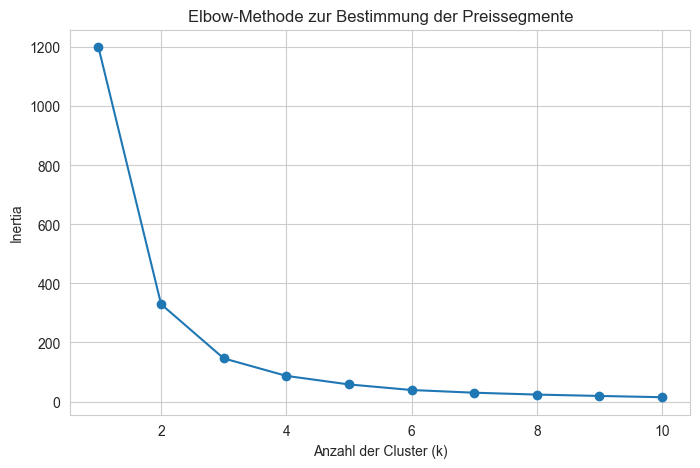

In [6]:
inertia = []

k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    k_range,
    inertia,
    marker="o"
)

plt.xlabel("Anzahl der Cluster (k)")
plt.ylabel("Inertia")
plt.title("Elbow-Methode zur Bestimmung der Preissegmente")

plt.show()

In [39]:
# 1.k=2
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=20)
df['Cluster_K2'] = kmeans_2.fit_predict(X_scaled)

# 2.k=3
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=20)
df['Cluster_K3'] = kmeans_3.fit_predict(X_scaled)

for col in ['Cluster_K2', 'Cluster_K3']:
    idx = df.groupby(col)['preis_euro'].mean().sort_values().index
    mapping = {old: new for new, old in enumerate(idx)}
    df[col] = df[col].map(mapping)

df['Segment_K3'] = df['Cluster_K3'].map({0: 'Niedrigpreis', 1: 'Mittelklasse', 2: 'Hochpreis'})
df['Segment_K2'] = df['Cluster_K2'].map({0: 'Budget Segment', 1: 'Premium Segment'})

In [7]:
scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)

silhouette_df = pd.DataFrame({
    "k": range(2, 11),
    "silhouette": scores
})

silhouette_df

,k,silhouette
0,2,0.616745
1,3,0.585884
2,4,0.562853
3,5,0.549126
4,6,0.557535
5,7,0.553963
6,8,0.540384
7,9,0.533858
8,10,0.549956


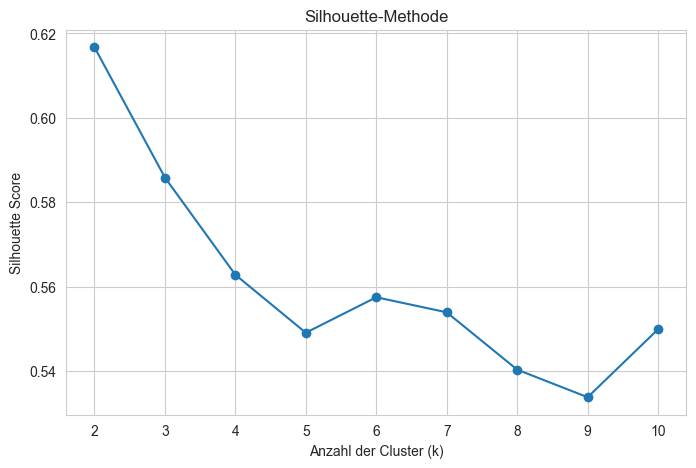

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    silhouette_df["k"],
    silhouette_df["silhouette"],
    marker="o"
)

plt.xlabel("Anzahl der Cluster (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette-Methode")

plt.show()

k = 2  
Silhouette = 0.617  
Die Silhouette-Analyse zeigt den höchsten Wert bei k = 2 (Silhouette = 0,617). Dies deutet darauf hin, dass der Datensatz natürlicherweise in zwei gut getrennte Preissegmente unterteilt werden kann. Daher wurde die Zielvariable „Preissegment“ in zwei Klassen definiert.  
k = 3 → Silhouette = 0.586  
Niedrigpreisige Fahrzeuge  
Mittelklassefahrzeuge  
Hochpreisige Fahrzeuge  
  
  Obwohl der höchste Silhouette-Koeffizient bei k = 2 erreicht wurde, weist auch die Lösung mit k = 3 einen hohen Wert von 0,586 auf. Da der Unterschied gering ist und drei Preissegmente aus fachlicher Sicht besser interpretierbar sind, wurde die Zielvariable in die Klassen „Niedrigpreis“, „Mittelklasse“ und „Hochpreis“ eingeteilt.

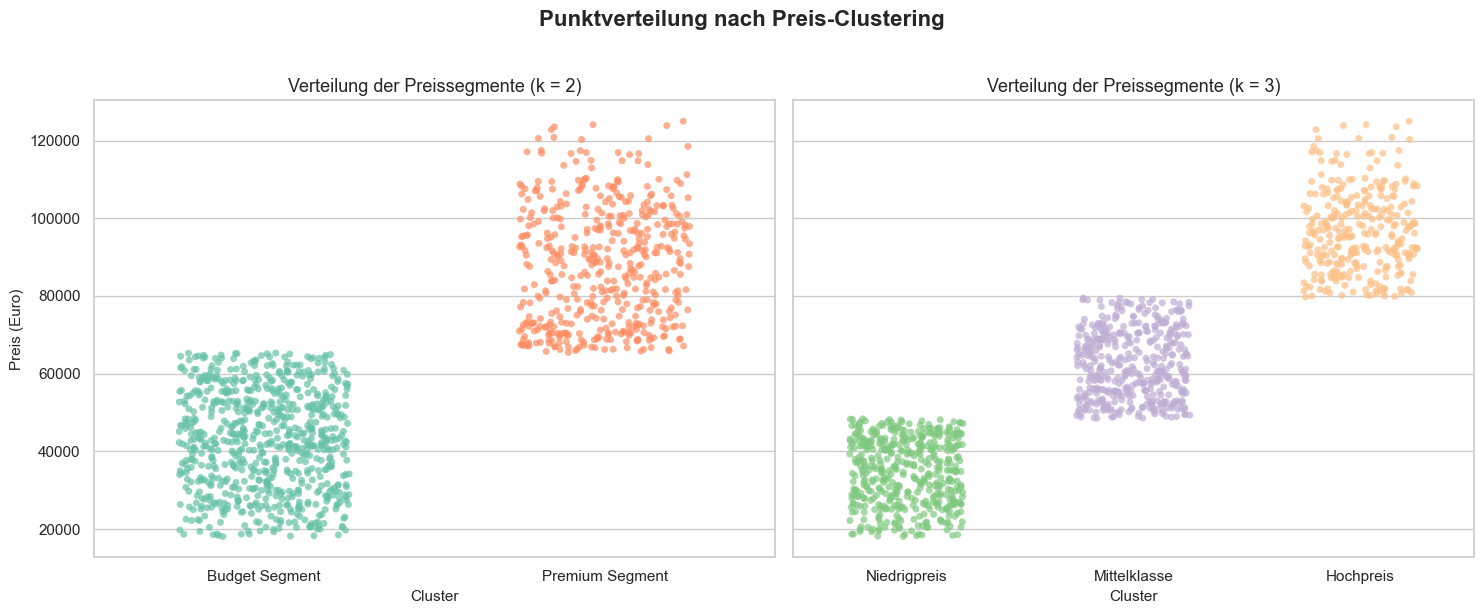

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Точки для k=2
sns.stripplot(
    ax=axes[0],
    x="Segment_K2",
    y="preis_euro",
    data=df.sort_values('Cluster_K2'),
    hue="Segment_K2",
    palette="Set2",
    jitter=0.25,
    size=5,
    alpha=0.7,
    legend=False
)
axes[0].set_title("Verteilung der Preissegmente (k = 2)", fontsize=13)
axes[0].set_xlabel("Cluster", fontsize=11)
axes[0].set_ylabel("Preis (Euro)", fontsize=11)

# Точки для k=3
sns.stripplot(
    ax=axes[1],
    x="Segment_K3",
    y="preis_euro",
    data=df.sort_values('Cluster_K3'),
    hue="Segment_K3",
    palette="Accent",
    jitter=0.25,
    size=5,
    alpha=0.7,
    legend=False
)
axes[1].set_title("Verteilung der Preissegmente (k = 3)", fontsize=13)
axes[1].set_xlabel("Cluster", fontsize=11)
axes[1].set_ylabel("")

plt.suptitle("Punktverteilung nach Preis-Clustering", fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

df["preis_segment"] = kmeans.fit_predict(
    df[["preis_euro"]]
)

In [27]:
segments = (
    df.groupby("preis_segment")["preis_euro"]
      .agg(["count", "min", "max", "mean"])
      .sort_values("mean")
)

segments

,count,min,max,mean
preis_segment,,,,
0,461,18086,48360,34729.295011
2,435,48545,79464,62288.374713
1,304,79716,124965,96837.226974


In [28]:
order = (
    df.groupby("preis_segment")["preis_euro"]
      .mean()
      .sort_values()
      .index
)

mapping = {
    order[0]: "Niedrigpreis",
    order[1]: "Mittelklasse",
    order[2]: "Hochpreis"
}

df["preis_segment"] = (
    df["preis_segment"]
      .map(mapping)
)

In [29]:
df["preis_segment"].value_counts()

preis_segment
Niedrigpreis    461
Mittelklasse    435
Hochpreis       304
Name: count, dtype: int64

In [13]:
df["preis_segment"].value_counts(normalize=True) * 100

preis_segment
Niedrigpreis    38.416667
Mittelklasse    36.250000
Hochpreis       25.333333
Name: proportion, dtype: float64

2.1  Numerische Variablen → Klassifikation nach Preissegmenten    
ANOVA und Mutual Information  

In [17]:
import pandas as pd
from scipy.stats import f_oneway
from sklearn.feature_selection import mutual_info_classif

numerical_features = ["verkaufszahl", "hubraum_l", "jahr", "monat"]

results_categorical = []

group_low = df[df["preis_segment"] == "Niedrigpreis"]
group_mid = df[df["preis_segment"] == "Mittelklasse"]
group_high = df[df["preis_segment"] == "Hochpreis"]

for col in numerical_features:
    
    g_low = group_low[col].dropna()
    g_mid = group_mid[col].dropna()
    g_high = group_high[col].dropna()

    if len(g_low) > 0 and len(g_mid) > 0 and len(g_high) > 0:
        f_stat, p_val = f_oneway(g_low, g_mid, g_high)
    else:
        f_stat, p_val = 0, 1

    #  Mutual Information
    X_curr = df[[col]].dropna()
    y_curr = df.loc[X_curr.index, "preis_segment"]

    # sklearn
    y_encoded = y_curr.astype("category").cat.codes

    mi_score = mutual_info_classif(
        X_curr, y_encoded, random_state=42, discrete_features=[False]
    )[0]

    results_categorical.append(
        {
            "Variable": col,
            "ANOVA_F_value": f_stat,  
            "p_value": p_val,  
            "Mutual_Information": mi_score,  
        }
    )

importance_df = pd.DataFrame(results_categorical)

# Mutual Information
importance_df = importance_df.sort_values(
    by="Mutual_Information", ascending=False
)

print("Analyse der Bedeutung numerischer Variablen für Preissegmente:")
importance_df

Analyse der Bedeutung numerischer Variablen für Preissegmente:


,Variable,ANOVA_F_value,p_value,Mutual_Information
2,jahr,1.457209,0.233298,0.016151
1,hubraum_l,0.049943,0.951286,0.015026
0,verkaufszahl,2.837484,0.058967,0.007205
3,monat,0.191130,0.826050,0.000000


Hier ist die statistische Interpretation der Ergebnisse:  
Mutual_Information ist fast Null:  
Die Werte für alle Variablen (max. $0.016$ bei jahr) zeigen, dass diese numerischen Merkmale fast keine messbare Information über das Preissegment liefern.   
Für ein ML-Modell haben sie isoliert betrachtet keinen Vorhersagewert.  
Keine statistische Signifikanz (p_value > 0.05):  
Alle $p$-Werte liegen über dem kritischen Schwellenwert von $0.05$ (z. B. jahr = $0.23$, hubraum_l = $0.95$).  
 Das bedeutet, dass sich die Mittelwerte dieser Variablen zwischen den Segmenten Niedrigpreis, Mittelklasse und Hochpreis nicht signifikant unterscheiden.   
 Die Gruppen sind statistisch gesehen in Bezug auf diese Daten identisch.  
 Bedeutung für die Praxis:monat (0.000000):   
 Der Monat hat absolut keinen Einfluss auf das Preissegment.  
  Ein Auto wird nicht teurer, nur weil es im Mai statt im Januar verkauft wurde.hubraum_l (0.015026): Überraschenderweise trennt der Hubraum die Segmente nicht. Das könnte an modernen Trends liegen (z. B. teure Elektroautos/Hybride mit kleinem oder ohne Hubraum).verkaufszahl (0.007205): Hat den höchsten ANOVA_F_value ($2.83$) und ein fast signifikantes p_value ($0.058$). Es gibt einen minimalen Trend (günstige Autos verkaufen sich oft in höheren Stückzahlen), aber der Effekt ist zu schwach für ein ML-Modell.💡 Empfehlung für dein ML-Modell: Deine numerischen Daten können die Preissegmente nicht erklären. Um ein präzises Modell zu bauen, musst du unbedingt die kategorialen Variablen nutzen: Marke (der stärkste Preistreiber!), Modell, Getriebe und Bundesland.

2.2 Kategoriale Variable - Klassifikation nach Preissegmenten   

$\chi^2$ Test of Independence - Pirson  
und Cramer's V

In [18]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

categorical_features = [
    "marke",
    "modell",
    "kraftstoff",
    "getriebe",
    "bundesland",
    "wochentag"
]

def cramers_v(x, y):
    # Cross-tabulation
    confusion_matrix = pd.crosstab(x, y)
    
    # Chi-squared test
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    # Bias correction for more accurate result
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    # Final coefficient
    if min((kcorr-1), (rcorr-1)) == 0:
        return 0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

results_cat = []

for col in categorical_features:
    # Run the classic Chi-square test to get the p-value
    confusion_matrix = pd.crosstab(df[col], df["preis_segment"])
    chi2_stat, p_val, dof, expected = chi2_contingency(confusion_matrix)
    
    v_score = cramers_v(df[col], df["preis_segment"])
    
    results_cat.append({
        "Variable": col,
        "Chi2_Statistic": chi2_stat, 
        "p_value": p_val,           
        "Cramers_V": v_score         
    })

# Erstellen Sie einen DataFrame für die Wichtigkeit der kategorialen Merkmale
categorical_importance = pd.DataFrame(results_cat)

# Sortieren Sie nach der Stärke der Beziehung Cramer's V (genau wie Sie nach eta_squared sortiert haben)
categorical_importance = (
    categorical_importance
    .sort_values(by="Cramers_V", ascending=False)
)

print("Analyse der Bedeutung kategorialer Merkmale für Preissegmente:")
categorical_importance

Analyse der Bedeutung kategorialer Merkmale für Preissegmente:


,Variable,Chi2_Statistic,p_value,Cramers_V
0,marke,838.956444,8.241562e-176,0.588904
1,modell,854.857539,8.667412e-155,0.583877
5,wochentag,22.035471,3.712419e-02,0.064686
2,kraftstoff,12.021789,6.148448e-02,0.050112
3,getriebe,2.201322,3.326511e-01,0.012904
4,bundesland,6.767018,7.472416e-01,0.000000


🏆 marke und modell sind die absoluten Top-Prädiktoren  
Cramers_V $\approx$ 0.58–0.59:  
 Dies deutet auf eine sehr starke Abhängigkeit hin. Die Marke und das Modell bestimmen fast im Alleingang, ob ein Auto im Segment Niedrigpreis, Mittelklasse oder Hochpreis landet.  
 p_value gegen Null (8.24e-176):  
  Die Wahrscheinlichkeit, dass dieser Zusammenhang zufällig ist, liegt bei Null.   
  Das ML-Modell wird seine Hauptregeln basierend auf diesen Variablen lernen.  
📅 wochentag und kraftstoff  
  Cramers_V $\approx$ 0.05–0.06:  
   Es gibt einen sehr schwachen Zusammenhang.  
   Wichtig bei wochentag (p_value = 0.037):  
    Der Wert liegt unter $0.05$, was bedeutet, dass der Zusammenhang statistisch signifikant ist.  
     Dies bestätigt unsere frühere Vermutung: Der Wochentag hat einen echten (wenn auch kleinen) Einfluss auf die Dynamik der Preissegmente.  
      Bei kraftstoff ($p = 0.061$) ist der Effekt nicht ganz signifikant.  
⚙️ getriebe und   
🗺️ bundesland  
Cramers_V $\approx$ 0.01 und 0.00:  
 Es gibt absolut keinen Zusammenhang.  
 p_value ($0.33$ und $0.74$):  
  Die Werte liegen weit über $0.05$.  
   Das bedeutet, dass die Getriebeart und das Bundesland in Bezug auf die Preissegmente rein zufällig verteilt sind.  
   Günstige und teure Autos werden unabhängig vom Bundesland oder Getriebe ähnlich oft gekauft.  
💡 ML-Empfehlung:  
 marke und modell sind Pflicht für dein Modell. wochentag und kraftstoff können als unterstützende Features beibehalten werden. getriebe und bundesland bieten jedoch keinen Mehrwert für die Vorhersage der Preissegmente.